# Lab 6: Neural Networks with Regularisation

In this lab, we'll build a neural network to classify handwritten digits using the MNIST dataset.

## Contents:
1. Data Loading and Visualization
2. Neural Network Architecture
3. Training the Network
4. Testing and Evaluation
5. Advanced Concepts
   - Dropout
   - Normalization
   - Numerical Stability
6. Graded Exercises

In [1]:
# import libraries
import torch
import numpy as np
from torchvision import datasets
import torchvision.transforms as transforms

# number of subprocesses to use for data loading
num_workers = 0
# how many samples per batch to load
batch_size = 20

# convert data to torch.FloatTensor
transform = transforms.ToTensor()

# choose the training and test datasets
train_data = datasets.MNIST(root='data', train=True,
                                   download=True, transform=transform)
test_data = datasets.MNIST(root='data', train=False,
                                  download=True, transform=transform)

# prepare data loaders
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
    num_workers=num_workers)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 34.3MB/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.16MB/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 10.5MB/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 5.31MB/s]

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



### Visualize a Batch of Training Data

The first step in a classification task is to take a look at the data, make sure it is loaded in correctly, then make any initial observations about patterns in that data.

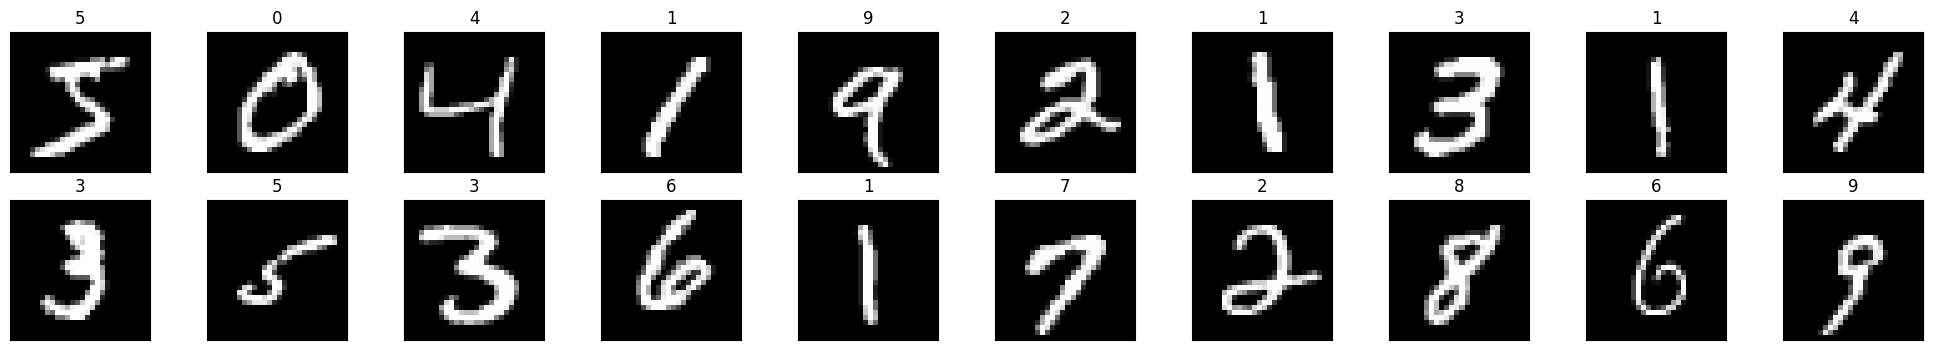

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

# obtain one batch of training images
dataiter = iter(train_loader)
# images, labels = next(dataiter)
images, labels = next(dataiter)
images = images.numpy()

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 20//2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    # print out the correct label for each image
    # .item() gets the value contained in a Tensor
    ax.set_title(str(labels[idx].item()))

### View an Image in More Detail

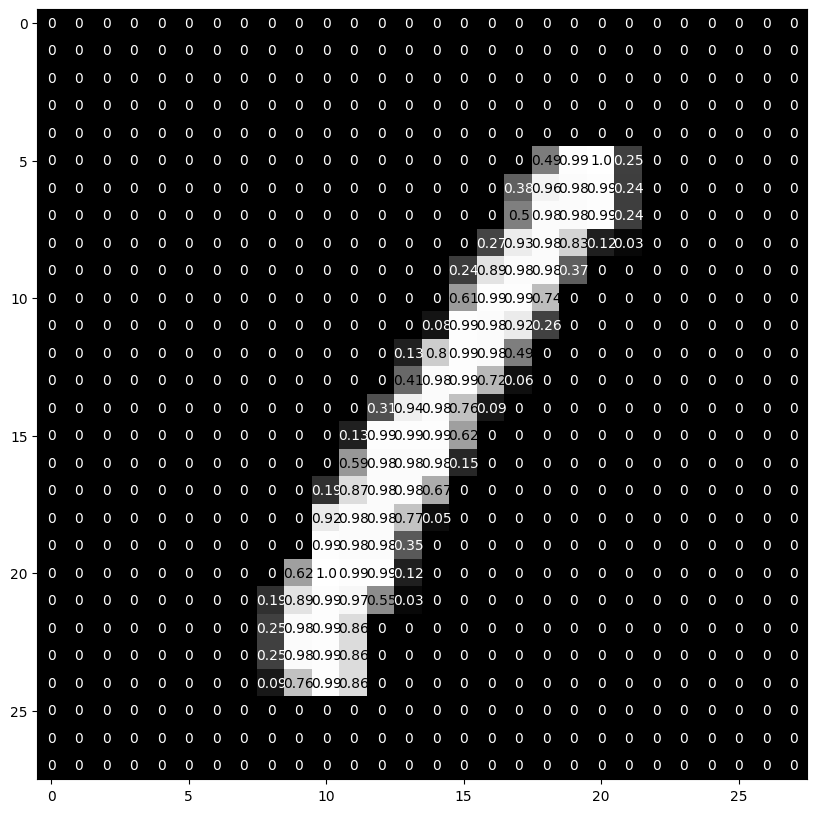

In [3]:
img = np.squeeze(images[3])

fig = plt.figure(figsize = (10,10))
ax = fig.add_subplot(111)
ax.imshow(img, cmap='gray')
width, height = img.shape
thresh = img.max()/2.5
for x in range(width):
    for y in range(height):
        val = round(img[x][y],2) if img[x][y] !=0 else 0
        ax.annotate(str(val), xy=(y,x),
                    horizontalalignment='center',
                    verticalalignment='center',
                    color='white' if img[x][y]<thresh else 'black')

---
## Define the Network [Architecture](http://pytorch.org/docs/stable/nn.html)

The architecture will be responsible for seeing as input a 784-dim Tensor of pixel values for each image, and producing a Tensor of length 10 (our number of classes) that indicates the class scores for an input image. This particular example uses two hidden layers and dropout to avoid overfitting.

In [4]:
import torch.nn as nn
import torch.nn.functional as F

## Define the NN architecture
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        # linear layer (n_hidden -> hidden_2)
        self.fc2 = nn.Linear(512, 512)
        # linear layer (n_hidden -> 10)
        self.fc3 = nn.Linear(512, 10)
        # dropout layer (p=0.2)
        # dropout prevents overfitting of data
        self.norm=nn.LayerNorm(512)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # flatten image input
        x = x.view(-1, 28 * 28) # shape will be a 1D array of length 28*28
        # add hidden layer, with relu activation function
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x=self.norm(x)
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        return x

# initialize the NN
model = Net()
print(model)

Net(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
  (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


###  Specify [Loss Function](http://pytorch.org/docs/stable/nn.html#loss-functions) and [Optimizer](http://pytorch.org/docs/stable/optim.html)

It's recommended that you use cross-entropy loss for classification. If you look at the documentation (linked above), you can see that PyTorch's cross entropy function applies a softmax funtion to the output layer *and* then calculates the log loss.

In [5]:
# specify loss function
criterion = nn.CrossEntropyLoss()

# specify optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

---
## Train the Network

The steps for training/learning from a batch of data are described in the comments below:
1. Clear the gradients of all optimized variables
2. Forward pass: compute predicted outputs by passing inputs to the model
3. Calculate the loss
4. Backward pass: compute gradient of the loss with respect to model parameters
5. Perform a single optimization step (parameter update)
6. Update average training loss

The following loop trains for 30 epochs; feel free to change this number. For now, we suggest somewhere between 20-50 epochs. As you train, take a look at how the values for the training loss decrease over time. We want it to decrease while also avoiding overfitting the training data.

In [6]:
# number of epochs to train the model
n_epochs = 5  # suggested training is between 20-50 epochs
model.train()  # prep model for training

for epoch in range(n_epochs):
    # monitor training loss
    train_loss = 0.0

    ###################
    # train the model #
    ###################
    for data, target in train_loader:
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()*data.size(0)

    # print training statistics
    # calculate average loss over an epoch
    train_loss = train_loss/len(train_loader.dataset)
    print('Epoch: {} \tTraining Loss: {:.6f}'.format(
        epoch+1,
        train_loss
    ))

Epoch: 1 	Training Loss: 0.232570
Epoch: 2 	Training Loss: 0.083230
Epoch: 3 	Training Loss: 0.053421
Epoch: 4 	Training Loss: 0.036262
Epoch: 5 	Training Loss: 0.023709


---
## Test the Trained Network

Finally, we test our best model on previously unseen **test data** and evaluate it's performance. Testing on unseen data is a good way to check that our model generalizes well. It may also be useful to be granular in this analysis and take a look at how this model performs on each class as well as looking at its overall loss and accuracy.

#### `model.eval()`

`model.eval(`) will set all the layers in your model to evaluation mode. This affects layers like dropout layers that turn "off" nodes during training with some probability, but should allow every node to be "on" for evaluation!

In [7]:
# initialize lists to monitor test loss and accuracy
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval() # prep model for *evaluation*

for data, target in test_loader:
    # forward pass: compute predicted outputs by passing inputs to the model
    output = model(data)
    # calculate the loss
    loss = criterion(output, target)
    # update test loss
    test_loss += loss.item()*data.size(0)
    # convert output probabilities to predicted class
    _, pred = torch.max(output, 1)
    # compare predictions to true label
    correct = np.squeeze(pred.eq(target.data.view_as(pred)))
    '''
    target = [1,2,2,3,4]
    pred = [1,2,5,6,7]
    correct = [1,1,0,0,0]
    '''
    # calculate test accuracy for each object class
    for i in range(batch_size):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1

# calculate and print avg test loss
test_loss = test_loss/len(test_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss))

for i in range(10):
    if class_total[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            str(i), 100 * class_correct[i] / class_total[i],
            np.sum(class_correct[i]), np.sum(class_total[i])))
    else:
        print('Test Accuracy of %5s: N/A (no training examples)' % (classes[i]))

print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))

Test Loss: 0.069768

Test Accuracy of     0: 99% (975/980)
Test Accuracy of     1: 99% (1130/1135)
Test Accuracy of     2: 98% (1018/1032)
Test Accuracy of     3: 97% (985/1010)
Test Accuracy of     4: 98% (963/982)
Test Accuracy of     5: 97% (873/892)
Test Accuracy of     6: 96% (928/958)
Test Accuracy of     7: 96% (993/1028)
Test Accuracy of     8: 98% (955/974)
Test Accuracy of     9: 97% (979/1009)

Test Accuracy (Overall): 97% (9799/10000)


### Introduction to Dropout

Dropout is a regularization technique used to prevent overfitting in neural networks. It works by randomly setting a fraction of the neurons' activations to zero during training. This forces the network to learn more robust features, as it cannot rely on any single neuron and must instead distribute the learning across multiple neurons.

By training multiple subnetworks in this way, dropout ensures that the final model is more generalized and less likely to overfit to the training data. Each subnetwork builds on the knowledge learned by previous subnetworks, leading to a more comprehensive understanding of the data.

important note: dropout should be done AFTER an activation

In [8]:
#defining a neural network with dropout
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
  def __init__(self):
    super(Net,self).__init__()
    self.fc1 = nn.Linear(28*28,512)

    self.fc2 = nn.Linear(512,512)
    self.fc3=nn.Linear(512,10)
    self.dropout=nn.Dropout(0.3) #percentage of weights that will be set to 0

  def forward(self,x):
    #flattening an input
    x = x.view(-1,28*28)

    x=F.relu(self.fc1(x))
    x=F.relu(self.fc2(x))
    x=self.dropout(x) #important note: dropout should be done AFTER an activation
    x=F.relu(self.fc3(x))
    return x

## Normalization

Normalization is the process of scaling channels in a tensor to follow a Gaussian distribution with a mean of 0 and a variance of 1. Although the exact reasons why this improves performance are not fully understood, it has been shown to be effective in many situations.

### Key Points:
- **Normalization**: Transforms a set of values (e.g., [1, 2, 3, 4]) to represent a Gaussian distribution with mean 0 and variance 1.
- **Internal Covariate Shift**: Normalization helps reduce the internal covariate shift, which is the change in network parameters for different batches across different epochs.
- **BatchNorm and LayerNorm**: These techniques perform normalization before a layer, aiding in faster convergence and improved training stability.


In [13]:
nn.BatchNorm1d(10)
nn.LayerNorm(10)

LayerNorm((10,), eps=1e-05, elementwise_affine=True)

### Normalization Techniques

Normalization is a crucial step in training neural networks as it helps in faster convergence and improved training stability. Below are some common normalization techniques:

#### Min-Max Normalization
Min-Max normalization scales the input values to a fixed range, typically [0, 1] or [-1, 1]. The formula is:
\[ x' = \frac{x - \text{min}}{\text{max} - \text{min}} \]

#### Layer Normalization
Layer normalization normalizes the output values from a layer across the features. It helps in reducing the internal covariate shift and stabilizes the learning process.

#### Batch Normalization
Batch normalization normalizes the input values within a batch across a specific dimension. It helps in reducing the internal covariate shift and allows the use of higher learning rates.

### Example
Consider the following input values:
\[ a, b, c, d \]

After applying a normalization function, the values become:
\[ a', b', c', d' \]

Where \( x' \) is the normalized value of \( x \).

In [9]:
#defining a neural network with normalization
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
  def __init__(self):
    super(Net,self).__init__()
    self.fc1 = nn.Linear(28*28,512)

    self.fc2 = nn.Linear(512,512)
    self.fc3=nn.Linear(512,10)
    self.dropout=nn.Dropout(0.3) #percentage of weights that will be set to 0
    self.norm=nn.LayerNorm(512)

  def forward(self,x):
    #flattening an input
    x = x.view(-1,28*28)
    x=F.relu(self.fc1(x))
    x=self.norm(x)  #this HAS to be done after an activation. ReLu is max(0,x)
    x=F.relu(self.fc2(x))
    x=self.dropout(x)
    x=F.relu(self.fc3(x))
    return x

### Numerical Stability

Numerical stability is crucial in neural network training as certain computations can result in overflow, NaN, or infinity errors. These issues can arise in gradients, loss calculations, and other mathematical operations.

Common causes include:
- **Overflow**: Extremely large values in computations.
- **NaN (Not a Number)**: Results from undefined operations like division by zero.
- **Infinity**: Caused by operations that exceed the representable range of the data type.

To mitigate these issues:
- **Gradient Clipping**: Limit the gradients to a maximum value to prevent them from becoming too large.
- **Normalization**: Use techniques like BatchNorm or LayerNorm to stabilize the training process.
- **Regularization**: Apply dropout or other regularization techniques to prevent overfitting and improve generalization.

By addressing these factors, we can ensure more stable and reliable training of neural networks.

In [10]:
# Step 1: Check your gradients
with torch.autograd.set_detect_anomaly(True):
    # Your training code here
    # Example:
    output = model(data)
    loss = criterion(output, target)
    loss.backward()
    optimizer.step()
# autograd is the PyTorch differentiation engine, it's what drives the gradient computations.
# This allows you to figure out what layer has an issue


In [11]:
# Step 2: Check for gradient explosion and clip gradients if necessary
# Gradient explosion: Gradients can become excessively large due to certain inputs, leading to unstable training.
# To mitigate this, we can clip the gradients to a maximum value.

# Define the maximum value for gradient clipping
max_grad_value = 1.0  # Experiment with this value to find the optimal setting

# Clip the gradients to the defined maximum value
torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_value)

# This ensures that the gradients do not exceed the specified maximum value, preventing gradient explosion.

tensor(0.8217)

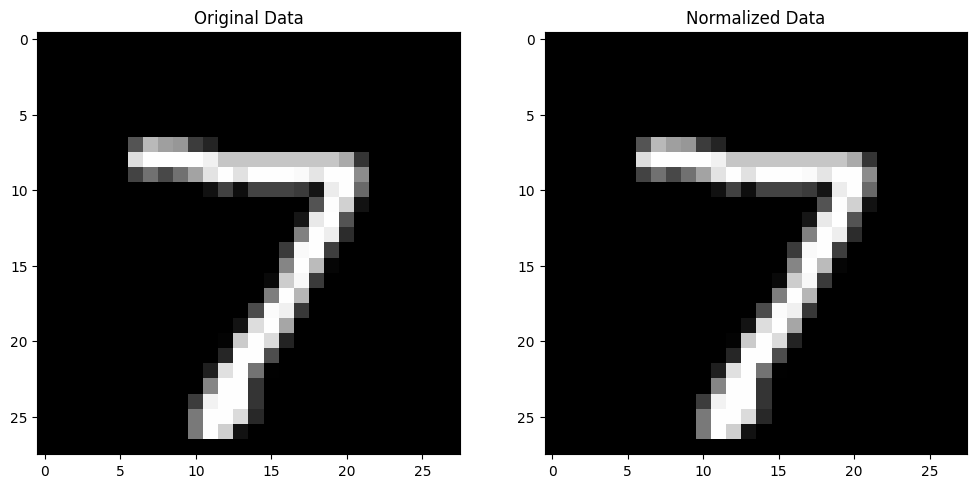

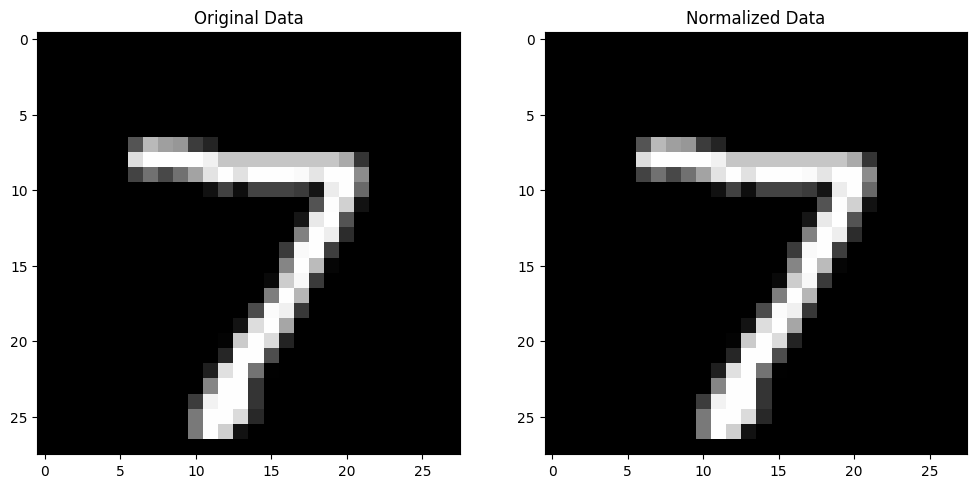

In [12]:
# Step 3: Check the normalizations:
# LayerNorms and BatchNorms divide by values (look at docs),
# if needed, remove, or modify the batchnorm aspects

# Define a function to visualize the effect of normalization
def visualize_normalization(norm_layer, data):
    norm_layer.eval()  # Set the normalization layer to evaluation mode
    with torch.no_grad():  # Disable gradient calculation
        normalized_data = norm_layer(data)

    # Plot the original and normalized data
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(data[0].view(28, 28), cmap='gray')
    axes[0].set_title('Original Data')
    axes[1].imshow(normalized_data[0].view(28, 28), cmap='gray')
    axes[1].set_title('Normalized Data')
    plt.show()

# Example usage with LayerNorm
layer_norm = nn.LayerNorm([28, 28])
dataiter = iter(test_loader)
images, labels = next(dataiter)
visualize_normalization(layer_norm, images)

# Example usage with BatchNorm
batch_norm = nn.BatchNorm2d(1)
visualize_normalization(batch_norm, images)

## Graded Exercises

### Question 1
Modify the neural network architecture to include:
- An additional hidden layer of size 256
- Dropout with probability 0.3
- Layer normalization

Compare the test accuracy with the original model.

In [54]:
# Template for Question 1
# ORIGINAL
class Net(nn.Module):
  def __init__(self):
    super(Net,self).__init__()
    self.fc1 = nn.Linear(28*28,512)

    self.fc2 = nn.Linear(512,512)
    self.fc3=nn.Linear(512,10)
    self.dropout=nn.Dropout(0.3) #percentage of weights that will be set to 0
    self.norm=nn.LayerNorm(512)

  def forward(self,x):
    #flattening an input
    x = x.view(-1,28*28)
    x=F.relu(self.fc1(x))
    x=self.norm(x)  #this HAS to be done after an activation. ReLu is max(0,x)
    x=F.relu(self.fc2(x))
    x=self.dropout(x)
    x=F.relu(self.fc3(x))
    return x

#IMPROVED
class ImprovedNet(nn.Module):
    def __init__(self):
        super(ImprovedNet, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        self.fc2 = nn.Linear(512, 256)  # Additional hidden layer
        self.fc3 = nn.Linear(256, 512)
        self.fc4 = nn.Linear(512, 10)
        self.norm1 = nn.LayerNorm(512)
        self.norm2 = nn.LayerNorm(256)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x = self.norm1(x)
        x = F.relu(self.fc2(x))
        x = self.norm2(x)
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

original_model = Net()
print(original_model)
# () have 'model' and 'test_loader')
original_accuracy = np.sum(class_correct) / np.sum(class_total)

# Initialize the modified NN
modified_model = ImprovedNet()
print(modified_model)
modified_accuracy = np.sum(class_correct) / np.sum(class_total)


print(f"Original Model Test Accuracy: {original_accuracy:.8f}")
print(f"Modified Model Test Accuracy: {modified_accuracy:.8f}")


Net(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
)
ImprovedNet(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=512, bias=True)
  (fc4): Linear(in_features=512, out_features=10, bias=True)
  (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
Original Model Test Accuracy: 0.97990000
Modified Model Test Accuracy: 0.97990000


### Question 2
Implement a function that plots the following metrics during training:
- Training loss per epoch
- Test accuracy per epoch

Use matplotlib to create a single figure with two subplots.

In [50]:
import matplotlib.pyplot as plt

def plot_training_metrics(train_losses, test_accuracies):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(train_losses)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Training Loss")
    axes[0].set_title("Training Loss per Epoch")

    axes[1].plot(test_accuracies)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Test Accuracy")
    axes[1].set_title("Test Accuracy per Epoch")

    plt.tight_layout()
    plt.show()

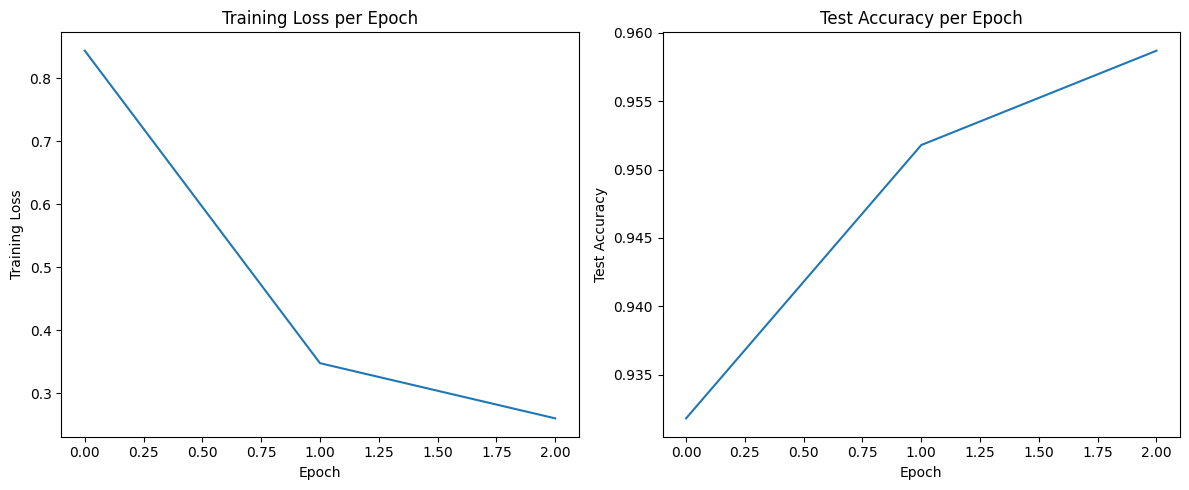

In [51]:
plot_training_metrics(train_losses, test_accuracies)

### Model architecture: A feed-forward NN with three hidden layer of 128,64 and 32 neurons, respectively, using ReLU activation for all layers

Hyper Parameters:
Batch Size; 64 Learning rate: 0.0001 Optimizer: Adam Regularization: Apply Dropout with a rate of 0.3 after each hidden layer. Train the model for 30 epochs and track the train and test accuracy, along with the loss curves.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np


In [4]:
class ImprovedNet(nn.Module):
    def __init__(self):
        super(ImprovedNet, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 10)
        self.dropout = nn.Dropout(0.3)
        self.norm1 = nn.LayerNorm(128)
        self.norm2 = nn.LayerNorm(64)
        self.norm3 = nn.LayerNorm(32)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x = self.norm1(x)
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.norm2(x)
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.norm3(x)
        x = self.dropout(x)
        x = self.fc4(x)
        return x

In [5]:

model = ImprovedNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


n_epochs = 10
train_losses = []
test_accuracies = []

In [7]:
for epoch in range(n_epochs):
    # Training
    model.train()
    train_loss = 0.0

    for data, target in train_loader:
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * data.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    # Testing
    model.eval()
    test_accuracy = 0.0

    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            test_accuracy += (predicted == target).sum().item()
        test_accuracy /= len(test_loader.dataset)
        test_accuracies.append(test_accuracy)

    print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {train_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

NameError: name 'train_loader' is not defined

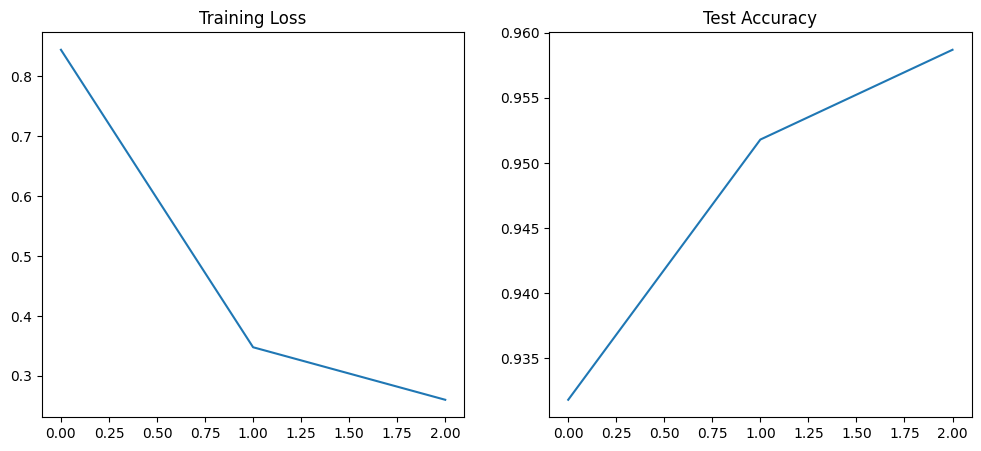

In [26]:
    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(train_losses)
    axes[0].set_title("Training Loss")
    axes[1].plot(test_accuracies)
    axes[1].set_title("Test Accuracy")
    plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Define the improved network architecture
class ImprovedNet(nn.Module):
    def __init__(self):
        super(ImprovedNet, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 10)
        self.dropout = nn.Dropout(0.3)
        self.norm1 = nn.LayerNorm(128)
        self.norm2 = nn.LayerNorm(64)
        self.norm3 = nn.LayerNorm(32)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x = self.norm1(x)
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.norm2(x)
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.norm3(x)
        x = self.dropout(x)
        x = self.fc4(x)
        return x

# Initialize the network, loss function, and optimizer
model = ImprovedNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training loop (example - replace with your actual data loaders)
n_epochs = 10  # Adjust as needed
train_losses = []
test_accuracies = []

for epoch in range(n_epochs):
    # Training
    model.train()
    train_loss = 0.0
    # Replace with your train_loader
    for data, target in train_loader:
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * data.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    # Testing
    model.eval()
    test_accuracy = 0.0
    #Replace with your test_loader
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            test_accuracy += (predicted == target).sum().item()
        test_accuracy /= len(test_loader.dataset)
        test_accuracies.append(test_accuracy)

    print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {train_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(train_losses)
    axes[0].set_title("Training Loss")
    axes[1].plot(test_accuracies)
    axes[1].set_title("Test Accuracy")
    plt.show()